In [1]:
# Install required libraries (if not installed)
# !pip install xgboost pandas numpy scikit-learn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# df = pd.read_csv("your_processed_data.csv")
file_path = r"H:\Master Files\cleaned_data.xlsx"

# Read the Excel file
df = pd.read_excel(file_path, engine="openpyxl")

# 🔹 Step 2: Convert 'Yes/No' to 1/0 for Binary Columns
binary_cols = [
    'Speech Delay/Language Disorder', 'Learning disorder', 'Genetic_Disorders',
    'Depression', 'Global developmental delay/intellectual disability',
    'Social/Behavioural Issues', 'Anxiety_disorder', 'Jaundice',
    'Family_mem_with_ASD', 'ASD_traits'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 🔹 Step 3: One-Hot Encode Categorical Columns
df = pd.get_dummies(df, columns=['Sex', 'Ethnicity', 'Who_completed_the_test'])

# 🔹 Step 4: Ensure All Data is Numeric
df = df.astype(float)

# 🔹 Step 5: Define Features (X) and Target (y)
X = df.iloc[:, :-1].values  # Features (all columns except last)
y = df.iloc[:, -1].values   # Target (last column)

# 🔹 Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 Step 7: Apply Basic XGBoost Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# 🔹 Step 8: Predict & Evaluate
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"🔹 Basic XGBoost Accuracy: {accuracy:.4f}")

# 🔹 Step 9: Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid_search = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), 
                           param_grid, scoring='accuracy', cv=3, n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

# 🔹 Step 10: Apply Best Model Found
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

# 🔹 Step 11: Final Accuracy After Optimization
final_accuracy = accuracy_score(y_test, y_pred_best)
print(f"✅ Optimized XGBoost Accuracy: {final_accuracy:.4f}")

c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:00:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


🔹 Basic XGBoost Accuracy: 0.9974
Fitting 3 folds for each of 108 candidates, totalling 324 fits
✅ Optimized XGBoost Accuracy: 0.9974


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:00:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [2]:

from sklearn.metrics import accuracy_score,jaccard_score, f1_score, precision_score, recall_score, mean_squared_error
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
jaccard = jaccard_score(y_test, y_pred, average='weighted')
mse = mean_squared_error(y_test, y_pred)

# Display results
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Jaccard Score: {jaccard:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

Accuracy: 0.9974
F1 Score: 0.9961
Precision: 0.9948
Recall: 0.9974
Jaccard Score: 0.9948
Mean Squared Error (MSE): 0.0026


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


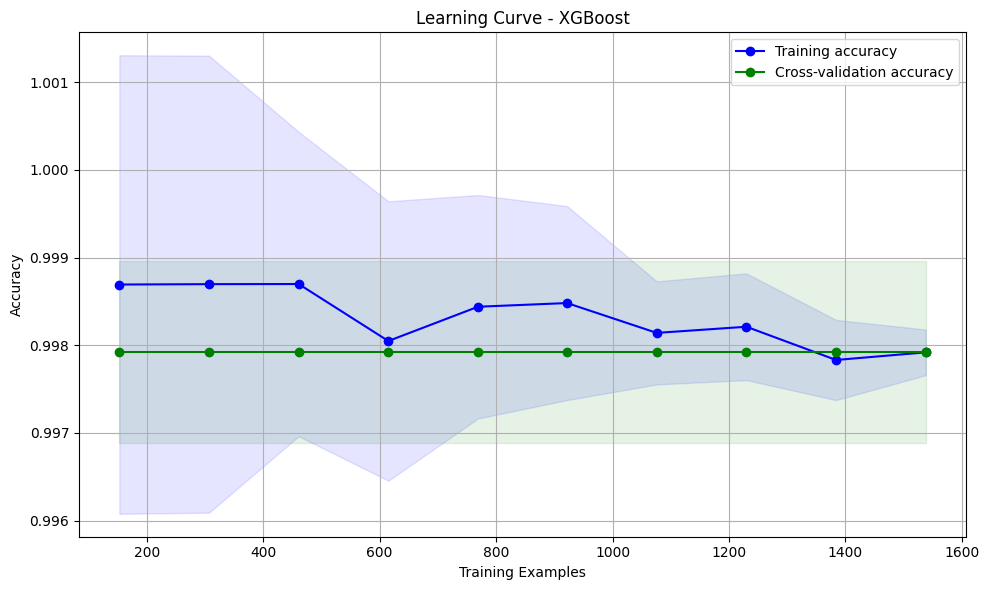

In [4]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# 🔹 Reuse the best model from GridSearchCV (or use a new instance if not done yet)
xgb_model = XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss',
    **grid_search.best_params_  # You can use best params from GridSearch
)

# 🔹 Get learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    estimator=xgb_model,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# 🔹 Calculate mean and std
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# 🔹 Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training accuracy')
plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Cross-validation accuracy')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color='green')
plt.title('Learning Curve - XGBoost')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


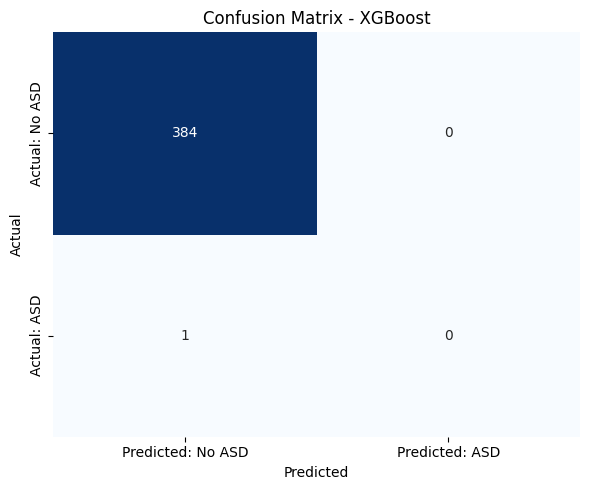

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 🔹 Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

# 🔹 Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted: No ASD', 'Predicted: ASD'],
            yticklabels=['Actual: No ASD', 'Actual: ASD'])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

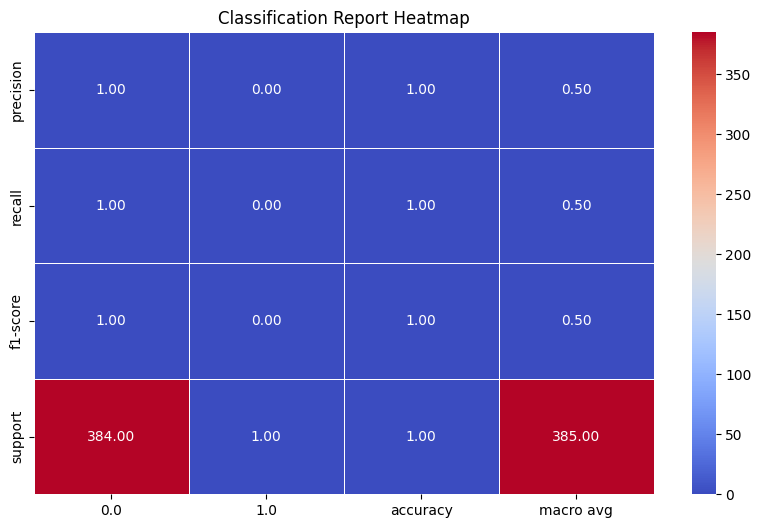

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd

# Generate the classification report as a dictionary
report = classification_report(y_test, y_pred_best, output_dict=True)

# Convert the dictionary to a DataFrame
report_df = pd.DataFrame(report).T

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :].T, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Classification Report Heatmap')
plt.show()

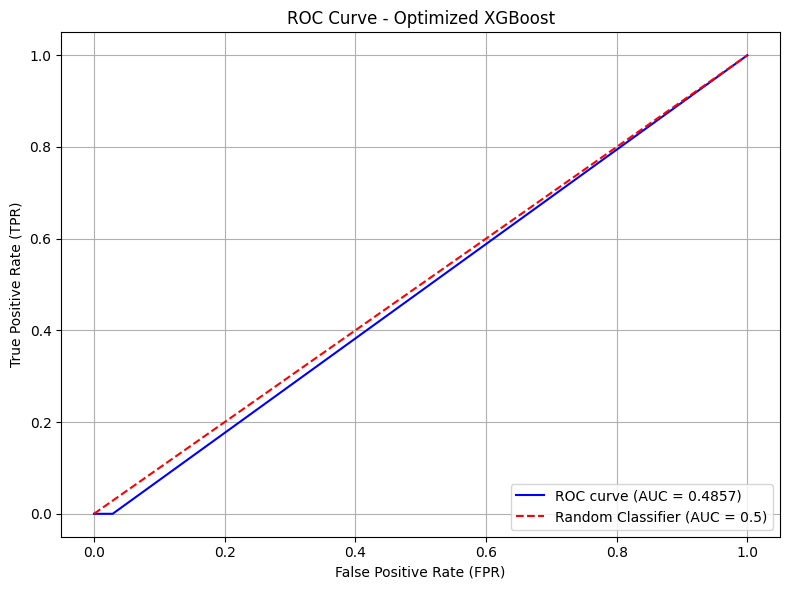

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 🔹 Compute ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, best_xgb.predict_proba(X_test)[:, 1])

# 🔹 Calculate AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# 🔹 Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - Optimized XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

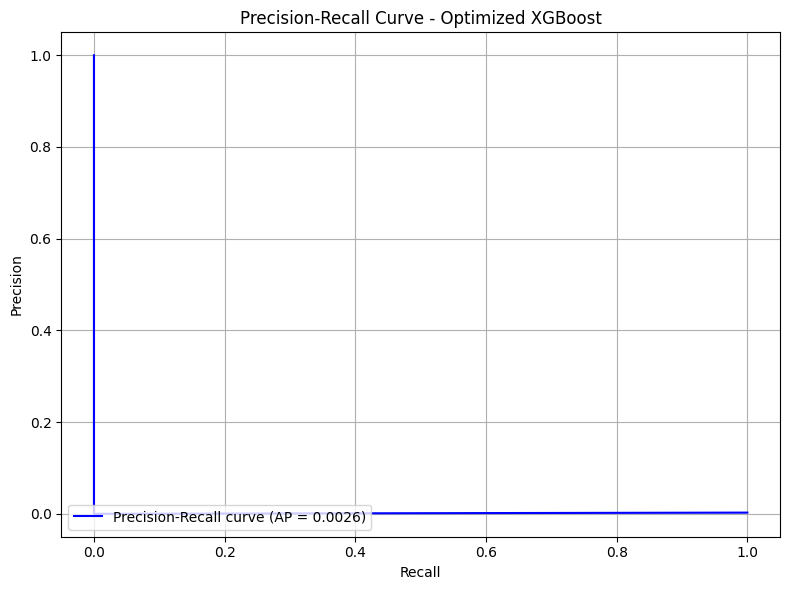

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# 🔹 Get Precision-Recall values for the optimized XGBoost model
precision, recall, _ = precision_recall_curve(y_test, best_xgb.predict_proba(X_test)[:, 1])

# 🔹 Calculate Average Precision (AP) Score
average_precision = average_precision_score(y_test, best_xgb.predict_proba(X_test)[:, 1])

# 🔹 Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'Precision-Recall curve (AP = {average_precision:.4f})')
plt.fill_between(recall, precision, color='blue', alpha=0.1)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Optimized XGBoost')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:13:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "probability", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:13:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "probability", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\AMT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:13:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "

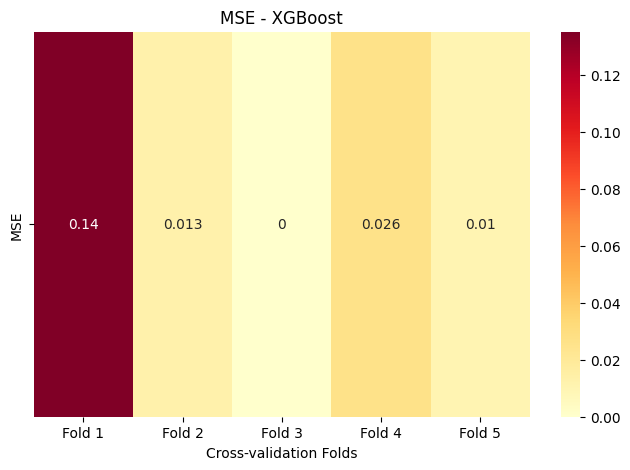

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, mean_squared_error
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset (replace this with your actual dataset)
file_path = r"H:\Master Files\cleaned_data.xlsx"
df = pd.read_excel(file_path, engine="openpyxl")

# Drop irrelevant columns and preprocess
df_cleaned = df.drop(columns=["CASE_NO_PATIENT'S"], errors='ignore')

# Encode categorical variables
label_encoders = {}
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le

# Feature selection (assuming 'ASD_traits' is the target)
X = df_cleaned.drop(columns=["ASD_traits"], errors='ignore')  # Features
y = df_cleaned["ASD_traits"]  # Target

# Initialize the XGBoost classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', probability=True)

# Create a custom scoring function for MSE
mse_scorer = make_scorer(mean_squared_error)

# Perform cross-validation to get MSE values
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring=mse_scorer)

# Visualization of MSE in a Single Rectangle
plt.figure(figsize=(8, 5))
sns.heatmap(cv_scores.reshape(1, -1), annot=True, cmap='YlOrRd', cbar=True, 
            xticklabels=[f'Fold {i+1}' for i in range(len(cv_scores))], 
            yticklabels=["MSE"])
plt.title('MSE - XGBoost')
plt.xlabel('Cross-validation Folds')
# plt.ylabel('MSE')
plt.show()
